In [66]:
import numpy as np

In [67]:
#code field ONLY needed because georinex doesnt show general time corrections....
import re
from pathlib import Path

# matches numbers like: -1.23E-09, 233472, -2.220446049E-15
NUM_RE = re.compile(r'[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[Ee][+-]?\d+)?')  #this gibberish is a search pattern that extracts sci numbers, needed because numbers like this -1.2805685401E-09-2.220446049E-15 are without space between them in rinex 3.x

def parse_rinex_utc_params(rnx_path: str):
    """
    Extract GPS->UTC (GPUT) and leap seconds from a RINEX 3 NAV header.
    If leap-second scheduling fields are missing, fill for simulation with:
      dtLSF = dtLS, WNLSF = 0, DN = 0
    Returns: dict(A0, A1, tot, WNt, dtLS, dtLSF, WNLSF, DN)
    """
    A0 = A1 = tot = WNt = None
    dtLS = dtLSF = WNLSF = DN = None

    with Path(rnx_path).open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            label = line[60:80].strip()

            if label == "END OF HEADER":
                break

            if label == "TIME SYSTEM CORR":
                corr_id = line[:4].strip()
                if corr_id == "GPUT":
                    nums = NUM_RE.findall(line[:60])
                    if len(nums) >= 4:
                        A0 = float(nums[0])
                        A1 = float(nums[1])
                        tot = int(float(nums[2]))
                        WNt = int(float(nums[3]))

            if label == "LEAP SECONDS":
                nums = NUM_RE.findall(line[:60])
                if len(nums) >= 1: dtLS  = int(float(nums[0]))
                if len(nums) >= 2: dtLSF = int(float(nums[1]))
                if len(nums) >= 3: WNLSF = int(float(nums[2]))
                if len(nums) >= 4: DN    = int(float(nums[3]))

    # Simulation-friendly defaults if missing
    if dtLS is not None:
        if dtLSF is None:
            dtLSF = dtLS
        if WNLSF is None:
            WNLSF = 0
        if DN is None:
            DN = 0

    return {
        "A0": A0, "A1": A1, "tot": tot, "WNt": WNt,
        "dtLS": dtLS, "dtLSF": dtLSF, "WNLSF": WNLSF, "DN": DN
    }


path = "BUDD00DNK_R_20260110000_01D_MN.rnx"
utc = parse_rinex_utc_params(path)
print(utc)
# should give approximately:
# {'A0': 1.8626451492e-09, 'A1': 5.329070518e-15, 'tot': 233472, 'WNt': 2401, 'dtLS': 18}

{'A0': 1.8626451492e-09, 'A1': 5.329070518e-15, 'tot': 233472, 'WNt': 2401, 'dtLS': 18, 'dtLSF': 18, 'WNLSF': 0, 'DN': 0}


In [68]:
import georinex as gr
import warnings
import pandas as pd

warnings.simplefilter("ignore", FutureWarning)

nav = gr.load("BUDD00DNK_R_20260110000_01D_MN.rnx",use="G")   # can also be .rnx.gz in many cases
#print(nav)  

# list GPS satellites present
gps_svs = [sv for sv in nav.sv.values if str(sv).startswith("G")]
#print("GPS SVs:", gps_svs[:10], "... total:", len(gps_svs))

tables = {}
# pick one SV at a time
for i in gps_svs:
    sv = i
    eph = nav.sel(sv=sv)
    nav.sel(sv=sv)["time"].values
    # show key orbital params if present
    keys = ['SVclockBias', 'SVclockDrift', 'SVclockDriftRate', 'IODE', 'Crs', 'DeltaN', 'M0', 'Cuc', 'Eccentricity', 'Cus', 'sqrtA', 'Toe', 'Cic', 'Omega0', 'Cis', 'Io', 'Crc', 'omega', 'OmegaDot', 'IDOT', 'GPSWeek', 'SVacc', 'health', 'TGD', 'IODC', 'TransTime',"GPSWeek","FitIntvl","time"]
    #keys = [k for k in keys if k in eph.data_vars]
    df = eph[keys].to_dataframe()

    iono = nav.attrs["ionospheric_corr_GPS"]
    alpha0, alpha1, alpha2, alpha3, beta0, beta1, beta2, beta3 = iono

    df = eph[keys].to_dataframe()

    df["alpha0"] = alpha0
    df["alpha1"] = alpha1
    df["alpha2"] = alpha2
    df["alpha3"] = alpha3
    df["beta0"]  = beta0
    df["beta1"]  = beta1
    df["beta2"]  = beta2
    df["beta3"]  = beta3

    iono = nav.attrs["ionospheric_corr_GPS"]
    cols = ["alpha0","alpha1","alpha2","alpha3","beta0","beta1","beta2","beta3"]
    df[cols] = iono  # broadcasts across all rows

    # Add UTC / leap second parameters as constant columns
    df["A0"]     = utc["A0"]
    df["A1"]     = utc["A1"]
    df["tot"]    = utc["tot"]
    df["WNt"]    = utc["WNt"]
    df["dtLS"]   = utc["dtLS"]
    df["dtLSF"]  = utc["dtLSF"]
    df["WNLSF"]  = utc["WNLSF"]
    df["DN"]     = utc["DN"]

    row = df.dropna(subset=["Toe"]).iloc[1]
    eph.to_dataframe().columns

    clean_df = df.dropna(subset=["Toe"]).query("TransTime < 604800")
    rows = []
    #print(i)
    for i in range(len(clean_df.dropna(subset=["Toe"]))):
        row = clean_df.iloc[i]
        params = {
            "sqrtA": row["sqrtA"],
            "e": row["Eccentricity"],
            "i0": row["Io"],
            "Omega0": row["Omega0"],
            "omega": row["omega"],
            "M0": row["M0"],
            "Toe": row["Toe"],
            "DeltaN": row["DeltaN"],
            "Cuc": row["Cuc"],
            "Cus": row["Cus"],
            "Cic": row["Cic"],
            "Cis": row["Cis"],
            "Crc": row["Crc"],
            "Crs": row["Crs"],
            "OmegaDot": row["OmegaDot"],
            "IDOT": row["IDOT"],
            "af0": row["SVclockBias"],
            "af1": row["SVclockDrift"],
            "af2": row["SVclockDriftRate"],
            "TGD": row["TGD"],
            "FitIntvl": row["FitIntvl"],
            "IODE": row["IODE"],
            "TOW": row["TransTime"],
            "GPSWeek": row["GPSWeek"],
            "IODC": row["IODC"],
            "URAIdx": row["SVacc"],
            "deltai": row["Io"],
            "TOA": row["Toe"],
            "alpha0": row["alpha0"],
            "alpha1": row["alpha1"],
            "alpha2": row["alpha2"],
            "alpha3": row["alpha3"],
            "beta0": row["beta0"],
            "beta1": row["beta1"],
            "beta2": row["beta2"],
            "beta3": row["beta3"],
            "A0" : row["A0"],
            "A1" : row["A1"],
            "tot" : row["tot"],
            "WNt" : row["WNt"],
            "dtLS" : row["dtLS"],
            "dtLSF" : row["dtLSF"],
            "WNLSF" : row["WNLSF"],
            "DN" : row["DN"],
            "WNa": row["GPSWeek"],
            "time": row.name,
        
        }



        rows.append({
            "sqrtA": row["sqrtA"],
            "e": row["Eccentricity"],
            "i0": row["Io"],
            "Omega0": row["Omega0"],
            "omega": row["omega"],
            "M0": row["M0"],
            "Toe": row["Toe"],
            "DeltaN": row["DeltaN"],
            "Cuc": row["Cuc"],
            "Cus": row["Cus"],
            "Cic": row["Cic"],
            "Cis": row["Cis"],
            "Crc": row["Crc"],
            "Crs": row["Crs"],
            "OmegaDot": row["OmegaDot"],
            "IDOT": row["IDOT"],
            "af0": row["SVclockBias"],
            "af1": row["SVclockDrift"],
            "af2": row["SVclockDriftRate"],
            "TGD": row["TGD"],
            "FitIntvl": row["FitIntvl"],
            "IODE": row["IODE"],
            "TOW": row["TransTime"],
            "GPSWeek": row["GPSWeek"],
            "IODC": row["IODC"],
            "URAIdx": row["SVacc"],
            "deltai": row["Io"],
            "TOA": row["Toe"],
            "alpha0": row["alpha0"],
            "alpha1": row["alpha1"],
            "alpha2": row["alpha2"],
            "alpha3": row["alpha3"],
            "beta0": row["beta0"],
            "beta1": row["beta1"],
            "beta2": row["beta2"],
            "beta3": row["beta3"],
            "A0" : row["A0"],
            "A1" : row["A1"],
            "tot" : row["tot"],
            "WNt" : row["WNt"],
            "dtLS" : row["dtLS"],
            "dtLSF" : row["dtLSF"],
            "WNLSF" : row["WNLSF"],
            "DN" : row["DN"],
            "WNa": row["GPSWeek"],
            "time": row.name,
        })

        
        #print(encode_gps_lnav_ephemeris(params))
    
        tables[sv] = pd.DataFrame(rows)

In [69]:
def solve_kepler_E(Mk, e, tol=1e-12, max_iter=50):
    """
    Solve Kepler's equation for eccentric anomaly E:
        Mk = E - e*sin(E)
    Inputs
      Mk : mean anomaly (rad). scalar or numpy array
      e  : eccentricity (0 <= e < 1). scalar or array-broadcastable to Mk
    Returns
      E  : eccentric anomaly (rad), same shape as Mk
    """
    Mk = np.asarray(Mk, dtype=float)
    e = np.asarray(e, dtype=float)

    # Wrap Mk to [-pi, pi] for better convergence
    M = (Mk + np.pi) % (2*np.pi) - np.pi

    # Initial guess (good for GNSS-like small e)
    E = M.copy()
    # Optional: slightly better guess when e is not tiny
    E = np.where(e > 0.8, np.pi * np.sign(M), E)

    for _ in range(max_iter):
        f = E - e * np.sin(E) - M
        fp = 1.0 - e * np.cos(E)

        dE = -f / fp
        E = E + dE

        if np.all(np.abs(dE) < tol):
            break
    else:
        raise RuntimeError("Kepler solver did not converge")

    # Unwrap back to same "branch" as original Mk (optional)
    # Return E in [0, 2pi) if you prefer:
    # E = E % (2*np.pi)

    return E

In [70]:
def R1(theta):
    return np.array([
        [1, 0, 0],
        [0, np.cos(theta), np.sin(theta)],
        [0, -np.sin(theta), np.cos(theta)]
    ])

def R3(theta):
    return np.array([
        [np.cos(theta), np.sin(theta), 0],
        [-np.sin(theta), np.cos(theta), 0],
        [0, 0, 1]
    ])

In [71]:
SV_input_dict = {
                1: "G01",
                2: "G02",
                3: "G03",
                4: "G04",
                5: "G05",
                6: "G06",
                7: "G07",
                8: "G08",
                9: "G09",
                10: "G10",
                11: "G11",
                12: "G12",
                13: "G13",
                14: "G14",
                15: "G15",
                16: "G16",
                17: "G17",
                18: "G18",
                19: "G19",
                20: "G20",
                21: "G21",
                22: "G22",
                23: "G23",
                24: "G24",
                25: "G25",
                26: "G26",
                27: "G27",
                28: "G28",
                29: "G29",
                30: "G30",
                31: "G31",
                32: "G32",
}

### lacation calc from ehpmeris data


https://gssc.esa.int/navipedia/index.php/GPS_and_Galileo_Satellite_Coordinates_Computation 

In [72]:
tables["G02"]["sqrtA"][0]**2

26559727.434559867

In [93]:
def ehpm_to_ECEFlocation(SV):
    #constant
    mu=3.986005*10**14 #m^3/s^2  earth grav const for gps user
    omegaDot_e=7.2921151467*10**-5 # rad/sec earth rotaion rate
    M_o=tables[SV_input_dict[SV]]["M0"][0]
    Deltan=tables[SV_input_dict[SV]]["DeltaN"][0]
    a=tables[SV_input_dict[SV]]["sqrtA"][0]**2
    e=tables[SV_input_dict[SV]]["e"][0]
    w=tables[SV_input_dict[SV]]["omega"][0]
    C_uc=tables[SV_input_dict[SV]]["Cuc"][0]
    C_us=tables[SV_input_dict[SV]]["Cus"][0]
    C_rs=tables[SV_input_dict[SV]]["Crs"][0]
    C_rc=tables[SV_input_dict[SV]]["Crc"][0]
    i_0 = tables[SV_input_dict[SV]]["i0"][0]
    i_dot = tables[SV_input_dict[SV]]["IDOT"][0]
    C_ic = tables[SV_input_dict[SV]]["Cic"][0]
    C_is = tables[SV_input_dict[SV]]["Cis"][0]
    Omega0 = tables[SV_input_dict[SV]]["Omega0"][0]
    OmegaDot = tables[SV_input_dict[SV]]["OmegaDot"][0]
    t=tables[SV_input_dict[SV]]["TOW"][0]
    t_oe=tables[SV_input_dict[SV]]["Toe"][0]

    #compute t_k
    t_k=t-t_oe
    if t_k > 302400:
        t_k-=604800
    elif t_k < -302400:
        t_k +=604800

    #compute mean anomaly fo t_k
    M_k=M_o+((np.sqrt(mu)/(np.sqrt(a**3)))+Deltan)*t_k

    E_k=solve_kepler_E(M_k,e)   #rad
    
    v_k = np.arctan2(np.sqrt(1 - e**2) * np.sin(E_k),
                 np.cos(E_k) - e)
    
    u_k=w+v_k+C_uc*np.cos(2*(w+v_k))+C_us*np.sin(2*(w+v_k))

    r_k=a*(1-e*np.cos(E_k))+C_rc*np.cos(2*(w+v_k))+C_rs*np.sin(2*(w+v_k))

    i_k = i_0 + i_dot * t_k + C_ic * np.cos(2 * (w + v_k)) + C_is * np.sin(2*(w + v_k))     # rad

    lambda_k = Omega0 + (OmegaDot - omegaDot_e)*t_k-omegaDot_e* t_oe

    rk_vec = np.array([r_k, 0, 0])

    XYZ = R3(-lambda_k) @ R1(-i_k) @ R3(-u_k) @ rk_vec

    return XYZ


In [83]:
ehpm_to_ECEFlocation("G01")/1000

array([20686.41950593, 12254.3478638 , 11357.19061639])

In [ ]:
import pandas as pd

target_time = pd.Timestamp("2026-01-11 02:00:00")
tol = pd.Timedelta(seconds=20)

selected_rows = []

for sv, table in tables.items():
    dt = (table["time"] - target_time).abs()

    if (dt <= tol).any():
        idx = dt.idxmin()           # index of closest epoch
        row = table.loc[idx].copy()
        row["sv"] = sv              # keep satellite label
        selected_rows.append(row)

# Combined result
result = pd.DataFrame(selected_rows).reset_index(drop=True)
result["sv"]

0     G01
1     G02
2     G03
3     G04
4     G06
5     G07
6     G09
7     G11
8     G12
9     G16
10    G17
11    G19
12    G21
13    G25
14    G26
15    G28
16    G31
Name: sv, dtype: str

##### Constants and variables


- $a$: Semi-major axis


- $f$: Flattening (skal vi bruge en kilde på. Har brugt værdien fra GP2)


- $e$: Eccentricity of ellipsoid (large: squashed earth, small: circular earth)


- $h$: Elevation at location N, E


- $N$: Breddegrad


- $E$: Længdegrad (english?)


- $\bar{N}(\phi)$: Radius of curvature. In the function $\phi = N$, because N is the name on Google Maps (when choosing a location)


$$\bar{N}(\phi) = \frac{a}{\sqrt{1 - e^2 sin^2 (\phi)}}$$


In [ ]:
a = 6378137.0                       # Halv storakse (Jordens radius)
f = 1 / 300                         # fra PP (GP2), flattening
e = np.sqrt(2*f - f**2)


def ECEF(N: float, E: float, h: float):         
   Nbar = a / (np.sqrt(1 - e**2*(np.sin(np.radians(N)))**2))


   # Cartesian (ECEF) coordinates in radians
   X = (Nbar + h) * np.cos(np.radians(N)) * np.cos(np.radians(E))
   Y = (Nbar + h) * np.cos(np.radians(N)) * np.sin(np.radians(E))
   Z = (Nbar * (1 - e**2) + h) * np.sin(np.radians(N))


   return X, Y, Z


ECEF(55.738957, 12.500242, 20)


(3513553.4182774397, 778951.6093149836, 5248286.552716679)

In [94]:
def paddelay(SV: int ,location: tuple):
    distnace_to_sat=np.sqrt(sum((ehpm_to_ECEFlocation(SV)-ECEF(55.738957, 12.500242, 20))**2))
    return round(distnace_to_sat/(3*10**8)*1000*1023) #1000 sec to ms, 1023 prn code length


buddinge=55.738957, 12.500242, 20
paddelay(1,buddinge)

73447

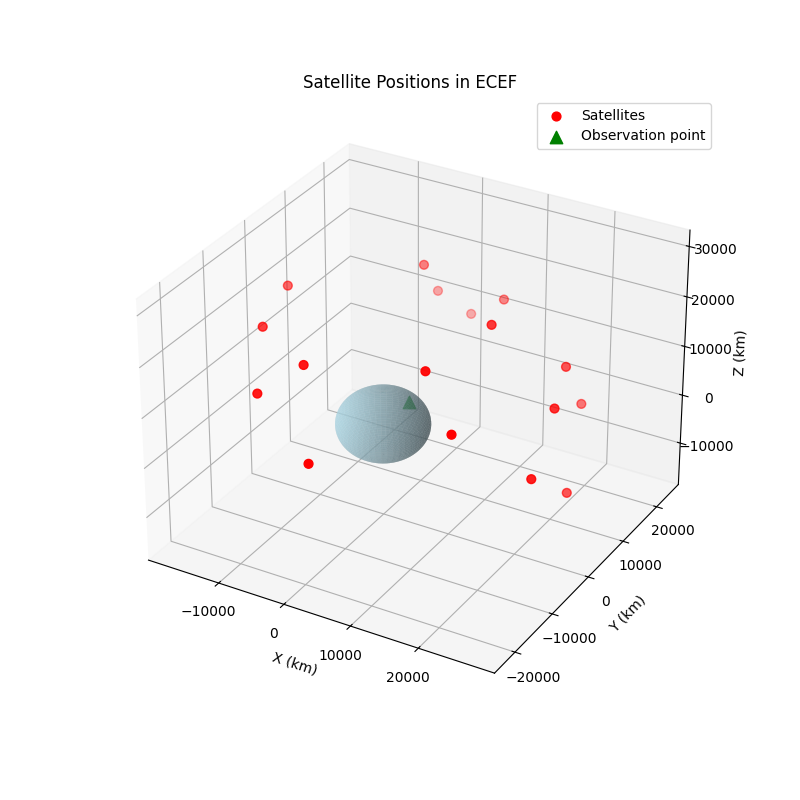

In [77]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Earth radius (km)
R_earth = 6371

# Example: get satellite positions
# Replace this with however you compute them
sat_positions = []

for prn in result["sv"]:  # GPS satellites
    pos = ehpm_to_ECEFlocation(prn) / 1000.0  # convert m -> km
    sat_positions.append(pos)

sat_positions = np.array(sat_positions)

# ---- Observation point (ECEF, km) ----
# Fill these in yourself (ECEF coordinates in km)
obs_x,obs_y,obs_z = ECEF(55.738957, 12.500242, 20)

obs_pos = np.array([obs_x/1000, obs_y/1000, obs_z/1000])

# ----- Create Earth sphere -----
u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, np.pi, 100)

x = R_earth * np.outer(np.cos(u), np.sin(v))
y = R_earth * np.outer(np.sin(u), np.sin(v))
z = R_earth * np.outer(np.ones(np.size(u)), np.cos(v))

# ----- Plot -----
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Earth
ax.plot_surface(x, y, z, color='lightblue', alpha=0.6)

# Satellites
ax.scatter(
    sat_positions[:,0],
    sat_positions[:,1],
    sat_positions[:,2],
    color='red',
    s=40,
    label='Satellites'
)

# Observation point
if None not in obs_pos:
    ax.scatter(
        obs_pos[0],
        obs_pos[1],
        obs_pos[2],
        color='green',
        s=80,
        marker='^',
        label='Observation point'
    )

# Equal axis scaling
max_range = np.array([
    sat_positions[:,0].max()-sat_positions[:,0].min(),
    sat_positions[:,1].max()-sat_positions[:,1].min(),
    sat_positions[:,2].max()-sat_positions[:,2].min()
]).max()/2

mid_x = (sat_positions[:,0].max()+sat_positions[:,0].min())/2
mid_y = (sat_positions[:,1].max()+sat_positions[:,1].min())/2
mid_z = (sat_positions[:,2].max()+sat_positions[:,2].min())/2

ax.set_xlim(mid_x-max_range, mid_x+max_range)
ax.set_ylim(mid_y-max_range, mid_y+max_range)
ax.set_zlim(mid_z-max_range, mid_z+max_range)

ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.set_title("Satellite Positions in ECEF")



plt.legend()
plt.show()

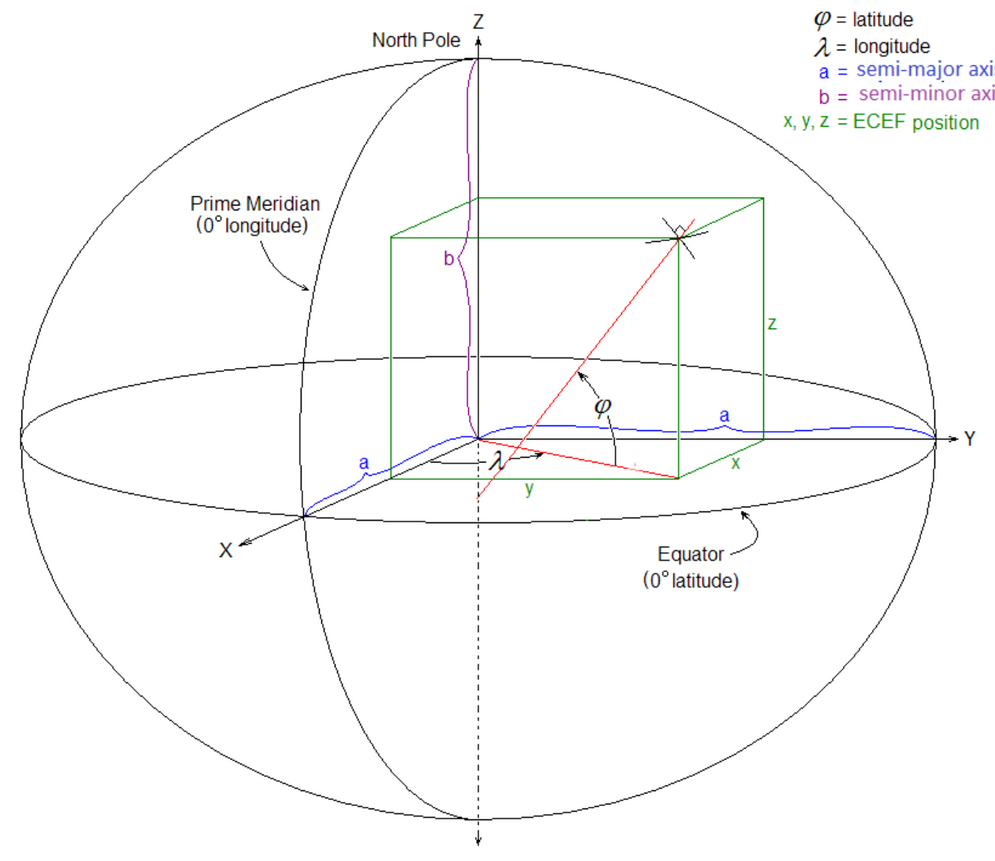

https://en.wikipedia.org/wiki/Earth-centered,_Earth-fixed_coordinate_system#/media/File:Ecef_coordinates.svg